# Task 1A

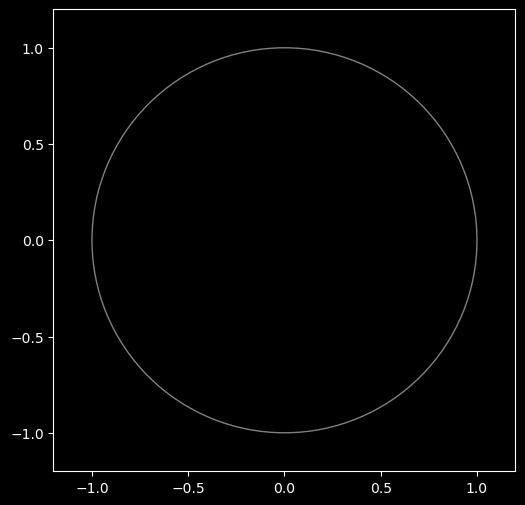

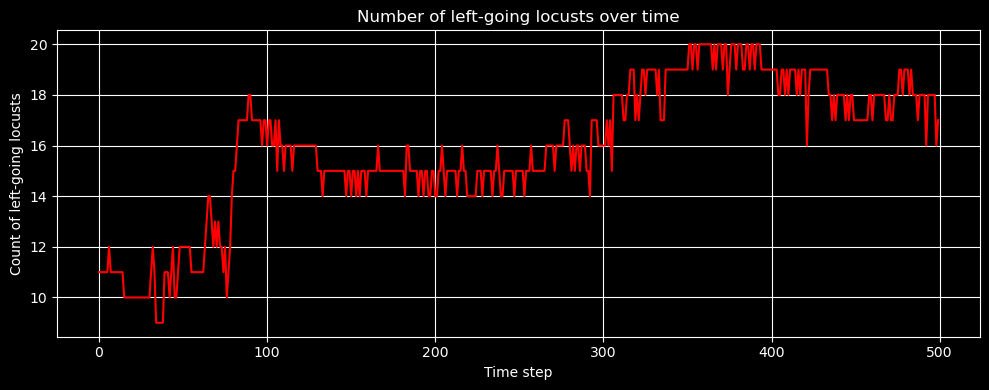

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# Parameters
N = 20
C = 1.0
v_abs = 0.001
r = 0.045
P = 0.015
timesteps = 500

# Initialization
positions = np.random.rand(N)
velocities = np.random.choice([-v_abs, v_abs], size=N)

# Store data for animation and plotting
positions_over_time = []
velocities_over_time = []
left_counts = []

for t in range(timesteps):
    new_velocities = velocities.copy()

    for i in range(N):
        # Compute ring distances
        distances = np.abs(positions - positions[i])
        distances = np.minimum(distances, C - distances)

        # Find neighbors
        in_range = (distances <= r) & (np.arange(N) != i)
        left = np.sum(velocities[in_range] < 0)
        right = np.sum(velocities[in_range] > 0)

        # Majority rule
        if velocities[i] < 0 and right > left:
            new_velocities[i] = v_abs
        elif velocities[i] > 0 and left > right:
            new_velocities[i] = -v_abs

        # Spontaneous switch
        if np.random.rand() < P:
            new_velocities[i] *= -1

    velocities = new_velocities
    positions = (positions + velocities) % C

    # Store data
    positions_over_time.append(positions.copy())
    velocities_over_time.append(velocities.copy())
    left_counts.append(np.sum(velocities < 0))

# --- Animation ---
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_aspect('equal')
circle = plt.Circle((0, 0), 1.0, color='gray', fill=False)
ax.add_artist(circle)
scat = ax.scatter([], [], s=80)

def init():
    ax.set_xlim(-1.2, 1.2)
    ax.set_ylim(-1.2, 1.2)
    return scat,

def update(frame):
    pos = positions_over_time[frame]
    vel = velocities_over_time[frame]
    angles = 2 * np.pi * pos
    x = np.cos(angles)
    y = np.sin(angles)
    colors = ['red' if v < 0 else 'blue' for v in vel]
    scat.set_offsets(np.c_[x, y])
    scat.set_color(colors)
    ax.set_title(f'Time: {frame} | Left-going: {np.sum(vel < 0)}')
    return scat,

ani = animation.FuncAnimation(fig, update, frames=timesteps,
                              init_func=init, blit=True, interval=30, repeat=False)

# Show animation
plt.show()

# --- Plot at the end ---
plt.figure(figsize=(10, 4))
plt.plot(left_counts, color='red')
plt.title('Number of left-going locusts over time')
plt.xlabel('Time step')
plt.ylabel('Count of left-going locusts')
plt.grid(True)
plt.tight_layout()
plt.show()


# Task 1B

Running simulations: 100%|██████████| 1000/1000 [01:55<00:00,  8.69it/s]


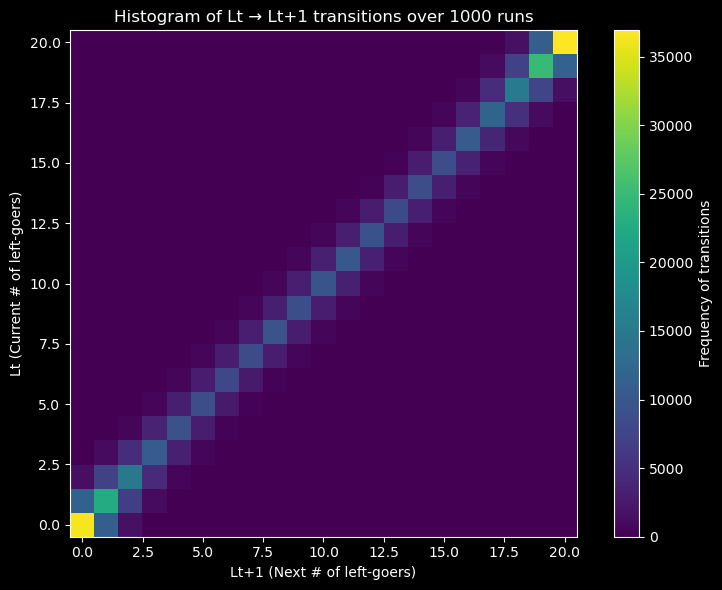

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm  # For progress bar

# Parameters
N = 20
C = 1.0
v_abs = 0.001
r = 0.045
P = 0.015
timesteps = 500
runs = 1000

# Initialize 2D histogram A[Lt][Lt+1]
A = np.zeros((N + 1, N + 1), dtype=int)

# Simulation loop
for run in tqdm(range(runs), desc="Running simulations"):
    positions = np.random.rand(N)
    velocities = np.random.choice([-v_abs, v_abs], size=N)

    left_count = np.sum(velocities < 0)

    for t in range(timesteps):
        new_velocities = velocities.copy()
        for i in range(N):
            # Compute ring distances
            distances = np.abs(positions - positions[i])
            distances = np.minimum(distances, C - distances)
            in_range = (distances <= r) & (np.arange(N) != i)
            left = np.sum(velocities[in_range] < 0)
            right = np.sum(velocities[in_range] > 0)

            # Majority switch
            if velocities[i] < 0 and right > left:
                new_velocities[i] = v_abs
            elif velocities[i] > 0 and left > right:
                new_velocities[i] = -v_abs

            # Spontaneous switch
            if np.random.rand() < P:
                new_velocities[i] *= -1

        velocities = new_velocities
        positions = (positions + velocities) % C

        # Next left count
        new_left_count = np.sum(velocities < 0)

        # Record transition
        A[left_count][new_left_count] += 1
        left_count = new_left_count

# Plot heatmap
plt.figure(figsize=(8, 6))
plt.imshow(A, origin='lower', cmap='viridis', interpolation='nearest')
plt.colorbar(label='Frequency of transitions')
plt.xlabel('Lt+1 (Next # of left-goers)')
plt.ylabel('Lt (Current # of left-goers)')
plt.title('Histogram of Lt → Lt+1 transitions over 1000 runs')
plt.tight_layout()
plt.show()


# Task 1C

Running simulations: 100%|██████████| 1/1 [00:00<00:00,  8.56it/s]


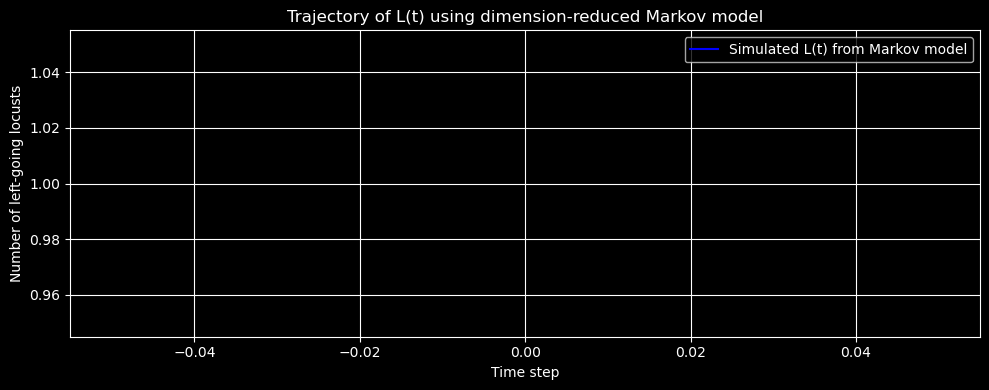

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# Parameters
N = 20
C = 1.0
v_abs = 0.001
r = 0.045
P = 0.015
timesteps = 500
runs = 1

# Initialize matrices
A = np.zeros((N + 1, N + 1), dtype=int)  # transition counts
M = np.zeros(N + 1, dtype=int)          # occurrence counts

# Run simulations
for run in tqdm(range(runs), desc="Running simulations"):
    positions = np.random.rand(N)
    velocities = np.random.choice([-v_abs, v_abs], size=N)
    left_count = np.sum(velocities < 0)

    for t in range(timesteps):
        new_velocities = velocities.copy()
        for i in range(N):
            distances = np.abs(positions - positions[i])
            distances = np.minimum(distances, C - distances)
            in_range = (distances <= r) & (np.arange(N) != i)
            left = np.sum(velocities[in_range] < 0)
            right = np.sum(velocities[in_range] > 0)

            if velocities[i] < 0 and right > left:
                new_velocities[i] = v_abs
            elif velocities[i] > 0 and left > right:
                new_velocities[i] = -v_abs

            if np.random.rand() < P:
                new_velocities[i] *= -1

        velocities = new_velocities
        positions = (positions + velocities) % C

        new_left_count = np.sum(velocities < 0)

        # Record transition and state count
        A[left_count][new_left_count] += 1
        M[left_count] += 1

        left_count = new_left_count

# Compute transition probabilities P[i][j] = A[i][j] / M[i]
P = np.zeros_like(A, dtype=float)
for i in range(N + 1):
    if M[i] > 0:
        P[i, :] = A[i, :] / M[i]

# --- Simulate Markov chain using P ---
L_trajectory = []
L = np.random.randint(0, N + 1)  # initial state

for t in range(timesteps):
    L_trajectory.append(L)
    probs = P[L]
    if probs.sum() == 0:  # no transition data; stay in place
        break
    L = np.random.choice(np.arange(N + 1), p=probs)

# --- Plot L_trajectory (dimension-reduced model) ---
plt.figure(figsize=(10, 4))
plt.plot(L_trajectory, label='Simulated L(t) from Markov model', color='blue')
plt.xlabel('Time step')
plt.ylabel('Number of left-going locusts')
plt.title('Trajectory of L(t) using dimension-reduced Markov model')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
